Nodes and state

In [1]:

%pip install --quiet -U langgraph>=1.0.0


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from IPython.display import Image, display
from typing import  List,  TypedDict, Annotated, operator
from langgraph.graph import END, START, StateGraph

In [3]:
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]

In [4]:
def node_a(state: State) -> State:
    #print(f"Node input for a: {state['nlist']}")
    note = "Hello World from Node a"
    return(State(nlist = [note]))

def node_b(state: State) -> State:
    #print(f"Node input for b: {state['nlist']}")
    note = "Hello World from Node b"
    return(State(nlist = [note]))

In [5]:
builder = StateGraph(State)

builder.add_node("a", node_a)
builder.add_node("b", node_b)

builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", END)
graph = builder.compile()

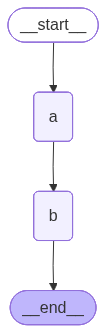

In [6]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
user_prompt = State(
    nlist = ["Hello Node a, how are you?"]
)
graph.invoke(user_prompt)

{'nlist': ['Hello Node a, how are you?',
  'Hello World from Node a',
  'Hello World from Node b']}

In [8]:
# Memory
# expected_state = {'nlist': ['Hello World from Node a','Hello World from Node b']}